##BanglaBert BiLSTM on Bangla Sentiment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Load


In [3]:
df = pd.read_csv("/content/Social Media Engagement Dataset.csv")
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,translated_text_content,hashtags,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকা...,#Food,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ...,"#MustHave, #Food",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?...,"#Promo, #Food, #Trending",...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 4:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে ...,"#Reviews, #Sustainable",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো ল...,"#Health, #Travel",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [12]:
selected_columns = ['text_content', 'translated_text_content', 'sentiment_label']
df = df[selected_columns]

In [5]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
Negative,4854
Positive,4839
Neutral,2307


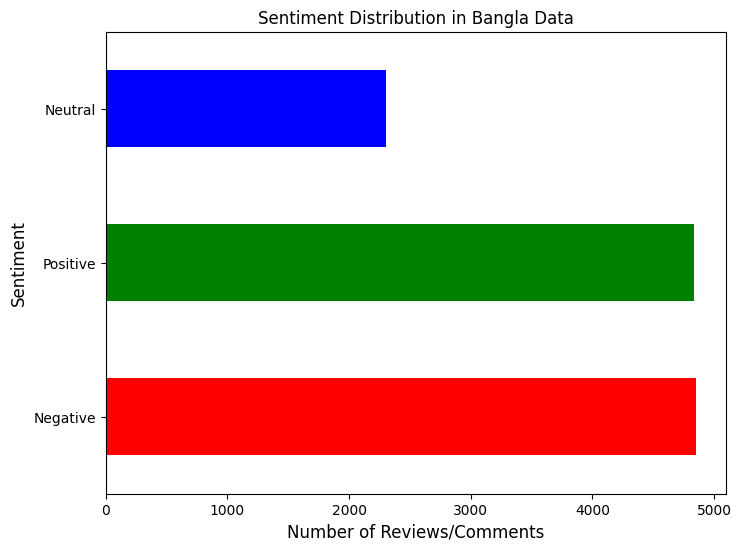

In [10]:
plt.figure(figsize=(8, 6))
df['sentiment_label'].value_counts().plot(kind='barh', color=['red', 'green', 'blue'])
plt.title('Sentiment Distribution in Bangla Data')
plt.xlabel('Number of Reviews/Comments',fontsize=12)
plt.ylabel('Sentiment',fontsize=12)
plt.show()

In [9]:
df.isnull().values.any()

np.True_

In [13]:
df.isnull().sum()

,0
text_content,0
translated_text_content,0
sentiment_label,0


Data Clean

In [17]:
import re
import unicodedata
import pandas as pd

def clean_bangla_text(text):
    """
    Standardizes and cleans Bengali/English text for BERT-BiLSTM training.
    Removes URLs, mentions, and all noise following hashtags.
    """
    if pd.isnull(text):
        return ""

    # 1. Normalize Unicode to ensure character consistency
    text = unicodedata.normalize('NFKC', str(text))

    # 2. Remove URLs and Social Media Mentions (@user)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\S+', '', text)

    # 3. Truncate at the first Hashtag
    # Based on dataset observation: everything from the first '#' onwards is noise
    if '#' in text:
        text = text.split('#')[0]

    # 4. Filter characters: Keep Bengali, English, Digits, and essential punctuation
    # Preserving punctuation like '।' and '.' helps BERT understand context
    text = re.sub(r'[^\u0980-\u09FFa-zA-Z0-9\s.,!?।]', ' ', text)

    # 5. Final whitespace normalization
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [18]:
df['clean_text'] = df['translated_text_content'].apply(clean_bangla_text)

In [19]:
pd.set_option('display.max_colwidth', None)
print(df[['translated_text_content', 'clean_text']].head())

                                                                                                 translated_text_content  \
0               গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা। #খাবার আপনার মতামত শুনতে সত্যিই আগ্রহী!   
1  স্প্রিংব্লাস্ট ২০২৫-এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই। #অবশ্যই খাওয়া, #খাবার।   
2            নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী? #প্রচার, #খাবার, #ট্রেন্ডিং আপনার মতামত শুনতে সত্যিই আগ্রহী!   
3                                                পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ। #পর্যালোচনা, #টেকসই   
4               টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে। #স্বাস্থ্য, #ভ্রমণ আপনার মতামত শুনতে সত্যিই আগ্রহী!   

                                                                                       clean_text  
0                                গুগল থেকে Chromebook ব্যবহার করে দেখুন। সর্বকালের সেরা কেনাকাটা।  
1  স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সারফেস ল্যাপট

In [20]:
pd.set_option('display.max_colwidth', None)

df['clean_text'].loc[1:5]

,clean_text
1,স্প্রিংব্লাস্ট ২০২৫ এর সময় মাইক্রোসফট সারফেস ল্যাপটপের একটা বিজ্ঞাপন দেখলাম। টাকার মূল্য নেই।
2,নাইকির এপিক রিঅ্যাক্ট সম্পর্কে আপনার মতামত কী?
3,পেপসির নতুন ডায়েট পেপসি দেখে হতাশ! মান নিয়ে হতাশ।
4,টয়োটার করোলাটা ট্রাই করলাম। সত্যিই খুব ভালো লেগেছে।
5,নাইকি পাওয়াররিলিজ তো খুবই খারাপ! এরপর কী আসছে তা দেখার জন্য অধীর আগ্রহে অপেক্ষা করছি।


Train-test split

In [21]:
from sklearn.model_selection import train_test_split

x = df['clean_text']
y = df['sentiment_label']


x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.15, random_state=42,  stratify=y_train_full)


print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_valid)}")
print(f"Testing set size: {len(x_test)}")



Training set size: 8160
Validation set size: 1440
Testing set size: 2400


Label Encoding

In [30]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

# Step 1: Label Encoding
y_train_le = le.fit_transform(y_train)
y_valid_le = le.transform(y_valid)
y_test_le  = le.transform(y_test)

# Step 2: One-Hot Encoding
y_train_ohe = to_categorical(y_train_le, num_classes=len(le.classes_))
y_valid_ohe = to_categorical(y_valid_le, num_classes=len(le.classes_))
y_test_ohe  = to_categorical(y_test_le,  num_classes=len(le.classes_))

print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))
print()
print("Example y_train (original):", y_train[:5].values)
print("After Label Encoding:      ", y_train_le[:5])
print("After One-Hot Encoding:\n",   y_train_ohe[:5])

Classes: ['Negative' 'Neutral' 'Positive']
Number of classes: 3

Example y_train (original): ['Neutral' 'Negative' 'Negative' 'Positive' 'Positive']
After Label Encoding:       [1 0 0 2 2]
After One-Hot Encoding:
 [[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


Tokenization and Padding

In [23]:
# Sequence length
lengths = [len(seq) for seq in x_train]

print("Max length:          ", max(lengths))
print("Min length:          ", min(lengths))
print("Mean length:         ", int(np.mean(lengths)))
print("Median length:       ", int(np.median(lengths)))
print("95th percentile:     ", int(np.percentile(lengths, 95)))
print("99th percentile:     ", int(np.percentile(lengths, 99)))

Max length:           121
Min length:           32
Mean length:          74
Median length:        74
95th percentile:      100
99th percentile:      110


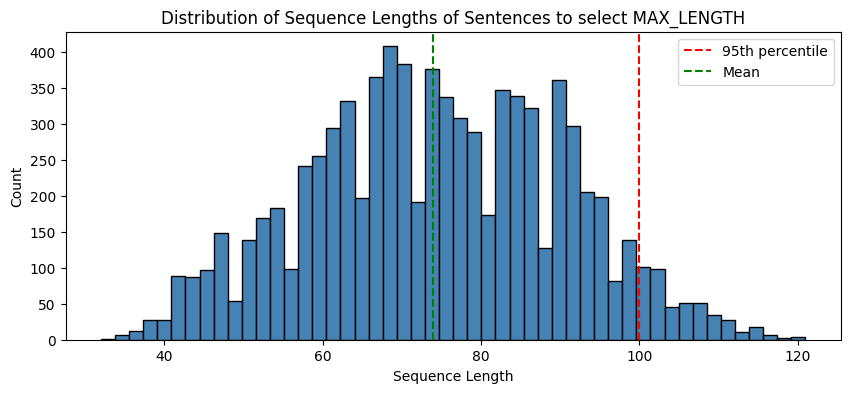

In [24]:
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(int(np.percentile(lengths, 95)), color='red',
            linestyle='--', label='95th percentile')
plt.axvline(int(np.mean(lengths)), color='green',
            linestyle='--', label='Mean')
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Distribution of Sequence Lengths of Sentences to select MAX_LENGTH")
plt.legend()
plt.show()

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization

tokenizer = Tokenizer(num_words=2000, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_valid_seq = tokenizer.texts_to_sequences(x_valid)
x_test_seq  = tokenizer.texts_to_sequences(x_test)


MAX_LEN = 130

x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
x_valid_pad = pad_sequences(x_valid_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
x_test_pad  = pad_sequences(x_test_seq,  maxlen=MAX_LEN, padding='pre', truncating='pre')


print("\nTrain Shape:", x_train_pad.shape)
print("Valid Shape:", x_valid_pad.shape)
print("Test Shape: ", x_test_pad.shape)





Train Shape: (8160, 130)
Valid Shape: (1440, 130)
Test Shape:  (2400, 130)


In [34]:
print("After Tokenization:", x_train_seq[0])
print("After padding:",x_train_pad[0])


After Tokenization: [30, 43, 175, 186, 31, 114, 72, 97]
After padding: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0  30  43 175 186
  31 114  72  97]


In [35]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 818


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 64
LSTM_UNITS = 128
MAX_LEN =130


classes  = np.unique(y_train_le)
weights = compute_class_weight('balanced', classes=classes, y=y_train_le)
class_weights = dict(zip(classes, weights))

print("Calculated class weights:", class_weights)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    x_train_pad, y_train_ohe,
    epochs = 20,
    batch_size = 64,
    validation_data = (x_valid_pad, y_valid_ohe),
    class_weight = class_weights,
    callbacks = [early_stopping],
    verbose = 1
)
model.summary()


Calculated class weights: {np.int64(0): np.float64(0.8239927294759164), np.int64(1): np.float64(1.7335882727852134), np.int64(2): np.float64(0.8267477203647416)}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 83s 575ms/step - accuracy: 0.8593 - loss: 0.4612 - val_accuracy: 0.9264 - val_loss: 0.1629
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 518ms/step - accuracy: 0.9278 - loss: 0.1493 - val_accuracy: 0.9354 - val_loss: 0.1299
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 506ms/step - accuracy: 0.9352 - loss: 0.1284 - val_accuracy: 0.9396 - val_loss: 0.1149
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 500ms/step - accuracy: 0.9409 - loss: 0.1194 - val_accuracy: 0.9368 - val_loss: 0.1116
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 490ms/step - accuracy: 0.9431 - loss: 0.1175 - val_accuracy: 0.9312 - val_loss: 0.1144
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 503ms/step - accuracy: 0.9431 - loss: 0.1143 - val_accuracy: 0.9424 - val_loss: 0.1085
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 497ms/step - accuracy: 0.9418 - loss: 0.1152 - val_accuracy: 0.9389 - val_loss: 0.1163
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 495ms/step - accuracy: 0.9438 - loss: 0.1139 - val

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 130, 64)        │        52,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 130, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,859 (1.74 MB)

 Trainable params: 151,619 (592.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 303,240 (1.16 MB)

In [40]:

# Training Accuracy (Final epoch)

train_acc = history.history['accuracy'][-1]

# Best Validation AccuracY
val_acc = max(history.history['val_accuracy'])

print("\n========== MODEL PERFORMANCE ==========")

print(f"Training Accuracy   : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")


# Test Accuracy (One-hot labels used)

print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test_pad, y_test_ohe, verbose=0)

print(f"Test Accuracy       : {test_acc*100:.2f}%")


========== MODEL PERFORMANCE ==========
Training Accuracy   : 94.47%
Validation Accuracy : 94.24%

Evaluating on Test Data...
Test Accuracy       : 92.62%


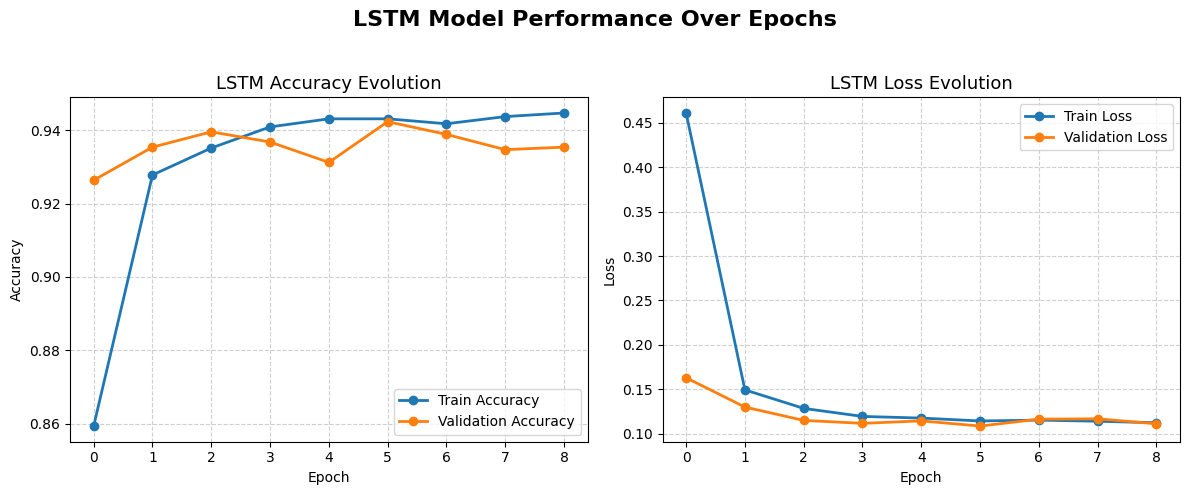

In [41]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,5))

# Overall title
plt.suptitle('LSTM Model Performance Over Epochs', fontsize=16, fontweight='bold')

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=2)
plt.title('LSTM Accuracy Evolution', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
plt.title('LSTM Loss Evolution', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93       971
     Neutral       0.94      0.90      0.92       461
    Positive       0.93      0.93      0.93       968

    accuracy                           0.93      2400
   macro avg       0.93      0.92      0.92      2400
weighted avg       0.93      0.93      0.93      2400



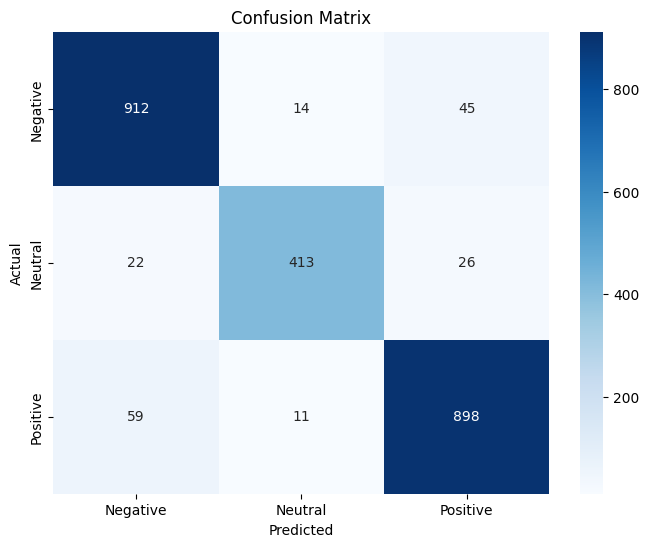

In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
y_pred = model.predict(x_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

print("\n--- Classification Report ---")

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()